In [6]:
import os
import boto3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
hour_df = pd.read_parquet("s3://dsan6000-wikipedia/hourly_parquet/20260901_040000.parquet")
hour_df.head()

,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


In [ ]:
# ! printf 'data\n*.parquet\n' >> .gitignore

In [9]:
NETID = "yk816"  # change to your NetID, lowercase
BUCKET = f"dsan6000-{NETID}"
PREFIX = "wikipedia-hourly/"

os.makedirs("images", exist_ok=True)

In [10]:
s3 = boto3.client("s3")
keys = []
for page in s3.get_paginator("list_objects_v2").paginate(Bucket=BUCKET, Prefix=PREFIX):
    keys += [o["Key"] for o in page.get("Contents", []) if o["Key"].endswith(".parquet")]
keys = sorted(keys)
print(len(keys), "files")

24 files


In [11]:
dfs = []
for key in keys:
    hour_df = pd.read_parquet(f"s3://{BUCKET}/{key}")
    # the hour comes from the file name, like 20260901_040000.parquet
    hour_df["hour"] = os.path.basename(key).replace(".parquet", "")
    dfs.append(hour_df)

df = pd.concat(dfs, ignore_index=True)
df["hour"] = pd.to_datetime(df["hour"], format="%Y%m%d_%H%M%S")
print(df.shape)
df.head()

(119708, 30)


,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str,hour
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00


In [13]:
print(df.columns.tolist())
EVENT_TYPE_COL = "type"  # change this if the event-type column has another name

['datetime', '$schema', 'meta', 'id', 'type', 'namespace', 'title', 'title_url', 'comment', 'timestamp', 'user', 'bot', 'notify_url', 'minor', 'length', 'revision', 'server_url', 'server_name', 'server_script_path', 'wiki', 'parsedcomment', 'log_id', 'log_type', 'log_action', 'log_params', 'log_action_comment', 'patrolled', 'file_ts', 'file_ts_str', 'hour']


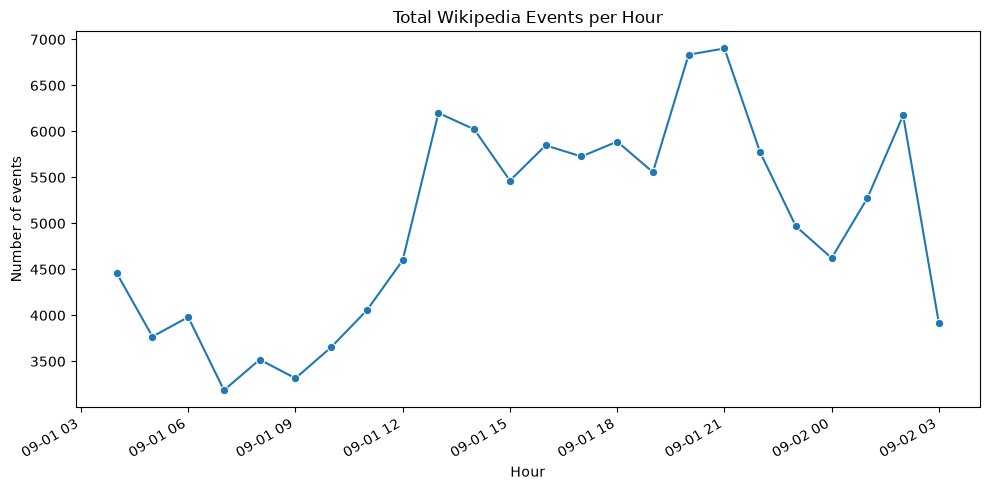

In [14]:
hourly = df.groupby("hour").size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=hourly, x="hour", y="count", marker="o", ax=ax)
ax.set_title("Total Wikipedia Events per Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Number of events")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("images/hourly-events.png", dpi=150)
fig.savefig("images/hourly-events.svg")
plt.show()

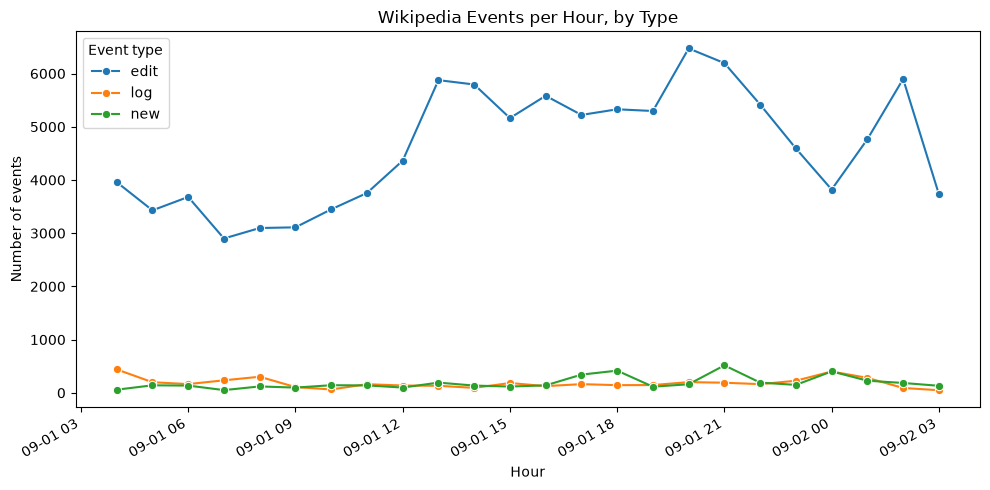

In [15]:
by_type = df.groupby(["hour", EVENT_TYPE_COL]).size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=by_type, x="hour", y="count", hue=EVENT_TYPE_COL, marker="o", ax=ax)
ax.set_title("Wikipedia Events per Hour, by Type")
ax.set_xlabel("Hour")
ax.set_ylabel("Number of events")
ax.legend(title="Event type")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("images/events-by-type.png", dpi=150)
fig.savefig("images/events-by-type.svg")
plt.show()